# Constraint-guided QAOA beyond MIS: multi-period portfolio optimisation (QOBLIB 06)

**Author:** Alberto Maldonado Romo (QOSF) · part of the `negsearch` repository.

**Question.** Can the *negation-forced* state preparation $A_q$ (constraints read as negative conditions) be used as the **initial state of QAOA** on a problem with real inequality constraints, and does it help compared with the usual penalty encodings?

**Problem.** QOBLIB class `06-portfolio`: at each period choose long and short positions in a set of S&P 500 assets, maximising return and minimising risk, transaction, short-selling and liquidation costs, subject to two inequalities per period:

$$\text{capital: } 0\le C-\underbrace{(\#\text{long}-\#\text{short})}_{\text{net}}\le 2^{c_1}-1, \qquad \text{budget: } 0\le B-\underbrace{(\#\text{long}+\#\text{short})}_{\text{total}}\le 2^{c_2}-1 .$$

The official QUBO enforces them with **binary slack qubits** and a quadratic penalty. Here the same constraints become negative conditions:

* a variable is **forced** when its other value would make the period's constraints impossible to complete (exact look-ahead on two small counters), otherwise it is a **coin** $R_Y(\theta_q)$;
* the resulting state $A_q|0\rangle$ has support **exactly on the feasible set** (no dead ends), with no slack qubits.

We compare five QAOA designs on three QOBLIB instances (exact statevector simulation), count CZ gates on `ibm_fez`, simulate the `ibm_fez` noise model, and prepare a hardware run.

| design | initial state | mixer | cost | stays feasible? |
|---|---|---|---|---|
| penalty, slack QUBO (QOBLIB model) | $|+\rangle^{\otimes n}$ | X | objective + $P\cdot$(slack penalty) | no |
| penalty, unbalanced (Montañez-Barrera et al.) | $|+\rangle^{\otimes n}$ | X | objective $-\lambda_1 g+\lambda_2 g^2$, no slack | no |
| $A_q$ + X mixer | $A_q|0\rangle$ | X | unbalanced | no |
| **$A_q$ + XY mixer (hybrid)** | $A_q|0\rangle$ | XY ring inside each (period, direction) block | objective | **yes** |
| **$A_q$ + Grover mixer (CG-QAOA)** | $A_q|0\rangle$ | $A_q e^{-i\beta|0\rangle\langle0|}A_q^\dagger$ | objective | **yes** |

In [1]:
import sys, json, math, time
sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from qiskit import transpile
from qiskit.quantum_info import Statevector
from negsearch.portfolio import Instance, Portfolio
from negsearch.portfolio_circuits import prep_circuit, qaoa_circuit
from negsearch.portfolio_qaoa import Sim
from experiments.portfolio_qaoa import INST, load, opt
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
# note: importing experiments.* switches the working directory to the repository root (data / results paths)

## 1. The instance and the official objective

`instances/qoblib_portfolio/` holds copies of the QOBLIB data (CC BY 4.0). We use one unit per asset and direction (`ub = 1`), so there is one binary variable per (period, direction, asset). The parameters are those of the ISQR submission to QOBLIB for this instance (`B = 3`, `C = 3`, `λ = 1e-5`). The objective reproduces the official checker (`06-portfolio/check`) exactly; the reference solution of the ISQR submission has objective **−1595**.

In [2]:
P = load('a003_t02')
print('assets:', P.inst.symbols, '| periods:', P.T, '| decision qubits:', P.nq)
print(f'budget B = {P.B}, capital C = {P.C}: per period  0 <= C - net <= {2**P.cs1-1},  0 <= B - total <= {2**P.cs2-1}')
x = np.zeros(P.nq, int); x[P.q(0, 1, P.inst.symbols.index('AAPL'))] = 1; x[P.q(0, 0, P.inst.symbols.index('MSFT'))] = 1
print('ISQR reference solution:', P.solution_lines(x), '-> objective', int(P.energy(x[None])[0]),
      '| feasible:', bool(P.feasible(x[None])[0]))
nsl = P.T * (P.cs1 + P.cs2)
print(f'slack QUBO of the reference model: {P.nq} + {nsl} slack = {P.nq + nsl} qubits')

assets: ['AAPL', 'NVDA', 'MSFT'] | periods: 2 | decision qubits: 12
budget B = 3, capital C = 3: per period  0 <= C - net <= 3,  0 <= B - total <= 3
ISQR reference solution: ['0 AAPL 0 1', '0 MSFT 1 0'] -> objective -1595 | feasible: True
slack QUBO of the reference model: 12 + 8 slack = 20 qubits


## 2. Negative conditions → forcing table → $A_q$

Inside a period the variables are processed in the order (long$_0$, short$_0$, long$_1$, …). The only state that matters is the pair of counters $(L,S)$ = (#long, #short) chosen so far. For each prefix state the planner checks, for each value of the next variable, whether *some* completion still satisfies both inequalities. If only one value survives, the variable is forced; this is the negation of the forbidden pattern "this choice makes the budget or capital impossible". Because the check is exact, the preparation never reaches a dead end.

In [3]:
order, act = P.plan()
for k, (d, i) in enumerate(order):
    forced = {st: v for st, v in act[k].items() if v != 'coin'}
    print(f"{'long ' if d == 0 else 'short'} {P.inst.symbols[i]:5s}: {len(act[k])} reachable (L,S) states, forced in {forced if forced else 'none'}")

long  AAPL : 1 reachable (L,S) states, forced in none
short AAPL : 2 reachable (L,S) states, forced in none
long  NVDA : 4 reachable (L,S) states, forced in none
short NVDA : 6 reachable (L,S) states, forced in {(0, 1): 0, (2, 1): 0, (1, 1): 0}
long  MSFT : 6 reachable (L,S) states, forced in {(0, 1): 1, (2, 1): 0}
short MSFT : 6 reachable (L,S) states, forced in {(2, 1): 0, (0, 0): 0, (1, 1): 0, (3, 0): 0}


In [4]:
q = 0.4
A = prep_circuit(P, q)
sv = Statevector(A).data.reshape(-1, 2 ** P.nq)
S = Sim(P)
print(f'A_q circuit: {A.num_qubits} qubits = {P.nq} decision + {A.num_qubits - P.nq} reusable counter ancillas')
print('ancillas returned to |0>:', np.allclose(sv[1:], 0, atol=1e-9))
print('equals the analytic state:', np.allclose(sv[0], P.prep_state(q), atol=1e-9))
print('support == feasible set:', np.array_equal(np.abs(sv[0]) > 1e-12, S.feas),
      f'({S.feas.sum()} feasible of {2**P.nq} bitstrings, uniform sampling hits feasible with p = {S.feas.mean():.3f})')

A_q circuit: 15 qubits = 12 decision + 3 reusable counter ancillas
ancillas returned to |0>: True
equals the analytic state: True
support == feasible set: True (676 feasible of 4096 bitstrings, uniform sampling hits feasible with p = 0.165)


**Classical baseline.** $A_q|0\rangle$ measured in the computational basis is a classical randomized algorithm (the classicality lemma of the paper): it can be sampled without a quantum computer. Every quantum method below must beat sampling $A_q$ to be useful.

## 3. Five QAOA designs, $p=1$, live on this instance

Metrics over the output distribution: **P(feasible)**, **normalised quality** $\mathbb E[\mathbb 1_{\text{feasible}}\,(f_{\max}-f)/(f_{\max}-f_{\text{opt}})]\in[0,1]$ (infeasible samples count 0), and **P(optimum)**. Penalty methods optimise their penalised energy; the constraint-preserving ones optimise the objective. A few seconds per method on 12 qubits.

In [5]:
sig = lambda z: 1 / (1 + np.exp(-z))
sc = 1 / np.abs(S.f).max(); cost = S.f * sc; D = float(np.abs(P.h).max()); p = 1
rng = np.random.default_rng(0); x0s = [rng.uniform(0, 1.5, 2 * p) for _ in range(4)]
rows = {}
hu, Ju, cu = P.unbalanced_poly(D / 16, D / 16); cpen = S.poly(hu, Ju, cu) * sc
r = opt(lambda x: float((np.abs(S.state('x', x[:p], x[p:], cpen)) ** 2 * cpen).sum()), x0s)
rows['penalty, unbalanced'] = S.metrics(S.state('x', r.x[:p], r.x[p:], cpen))
for name, kind in (('A_q + XY mixer', 'xy'), ('A_q + Grover mixer', 'grover')):
    f = lambda x: float((np.abs(S.state(kind, x[:p], x[p:2*p], cost, P.prep_state(sig(x[-1])))) ** 2 * cost).sum())
    r = opt(f, [np.r_[x, 0.0] for x in x0s]); rows[name] = dict(q=float(sig(r.x[-1])),
        **S.metrics(S.state(kind, r.x[:p], r.x[p:2*p], cost, P.prep_state(sig(r.x[-1])))))
    if kind == 'xy': best_xy = r.x
qs = np.linspace(0.05, 0.95, 19); mq = [S.metrics(P.prep_state(v)) for v in qs]; b = int(np.argmax([m['quality'] for m in mq]))
rows['A_q alone (classical sampling)'] = dict(q=float(qs[b]), **mq[b])
rows['uniform sampling'] = S.metrics(np.ones(2 ** P.nq) / 2 ** (P.nq / 2))
for k, v in rows.items():
    print(f"{k:32s} P(feasible) = {v['p_feas']:.3f}   quality = {v['quality']:.3f}   P(opt) = {v['p_opt']:.4f}")

penalty, unbalanced              P(feasible) = 0.630   quality = 0.503   P(opt) = 0.0062
A_q + XY mixer                   P(feasible) = 1.000   quality = 0.755   P(opt) = 0.0312
A_q + Grover mixer               P(feasible) = 1.000   quality = 0.787   P(opt) = 0.1200
A_q alone (classical sampling)   P(feasible) = 1.000   quality = 0.647   P(opt) = 0.0349
uniform sampling                 P(feasible) = 0.165   quality = 0.082   P(opt) = 0.0002


## 4. Full study: three instances, $p=1,2,3$

Produced by `experiments/portfolio_qaoa.py` (main run) and `experiments/portfolio_penalty_scan.py` (penalty weights re-tuned down to $\alpha=1/64$ of the largest coefficient, best value kept, so the penalty baselines are not under-tuned). The slack-QUBO baseline is simulated only where it fits in memory (20 qubits).

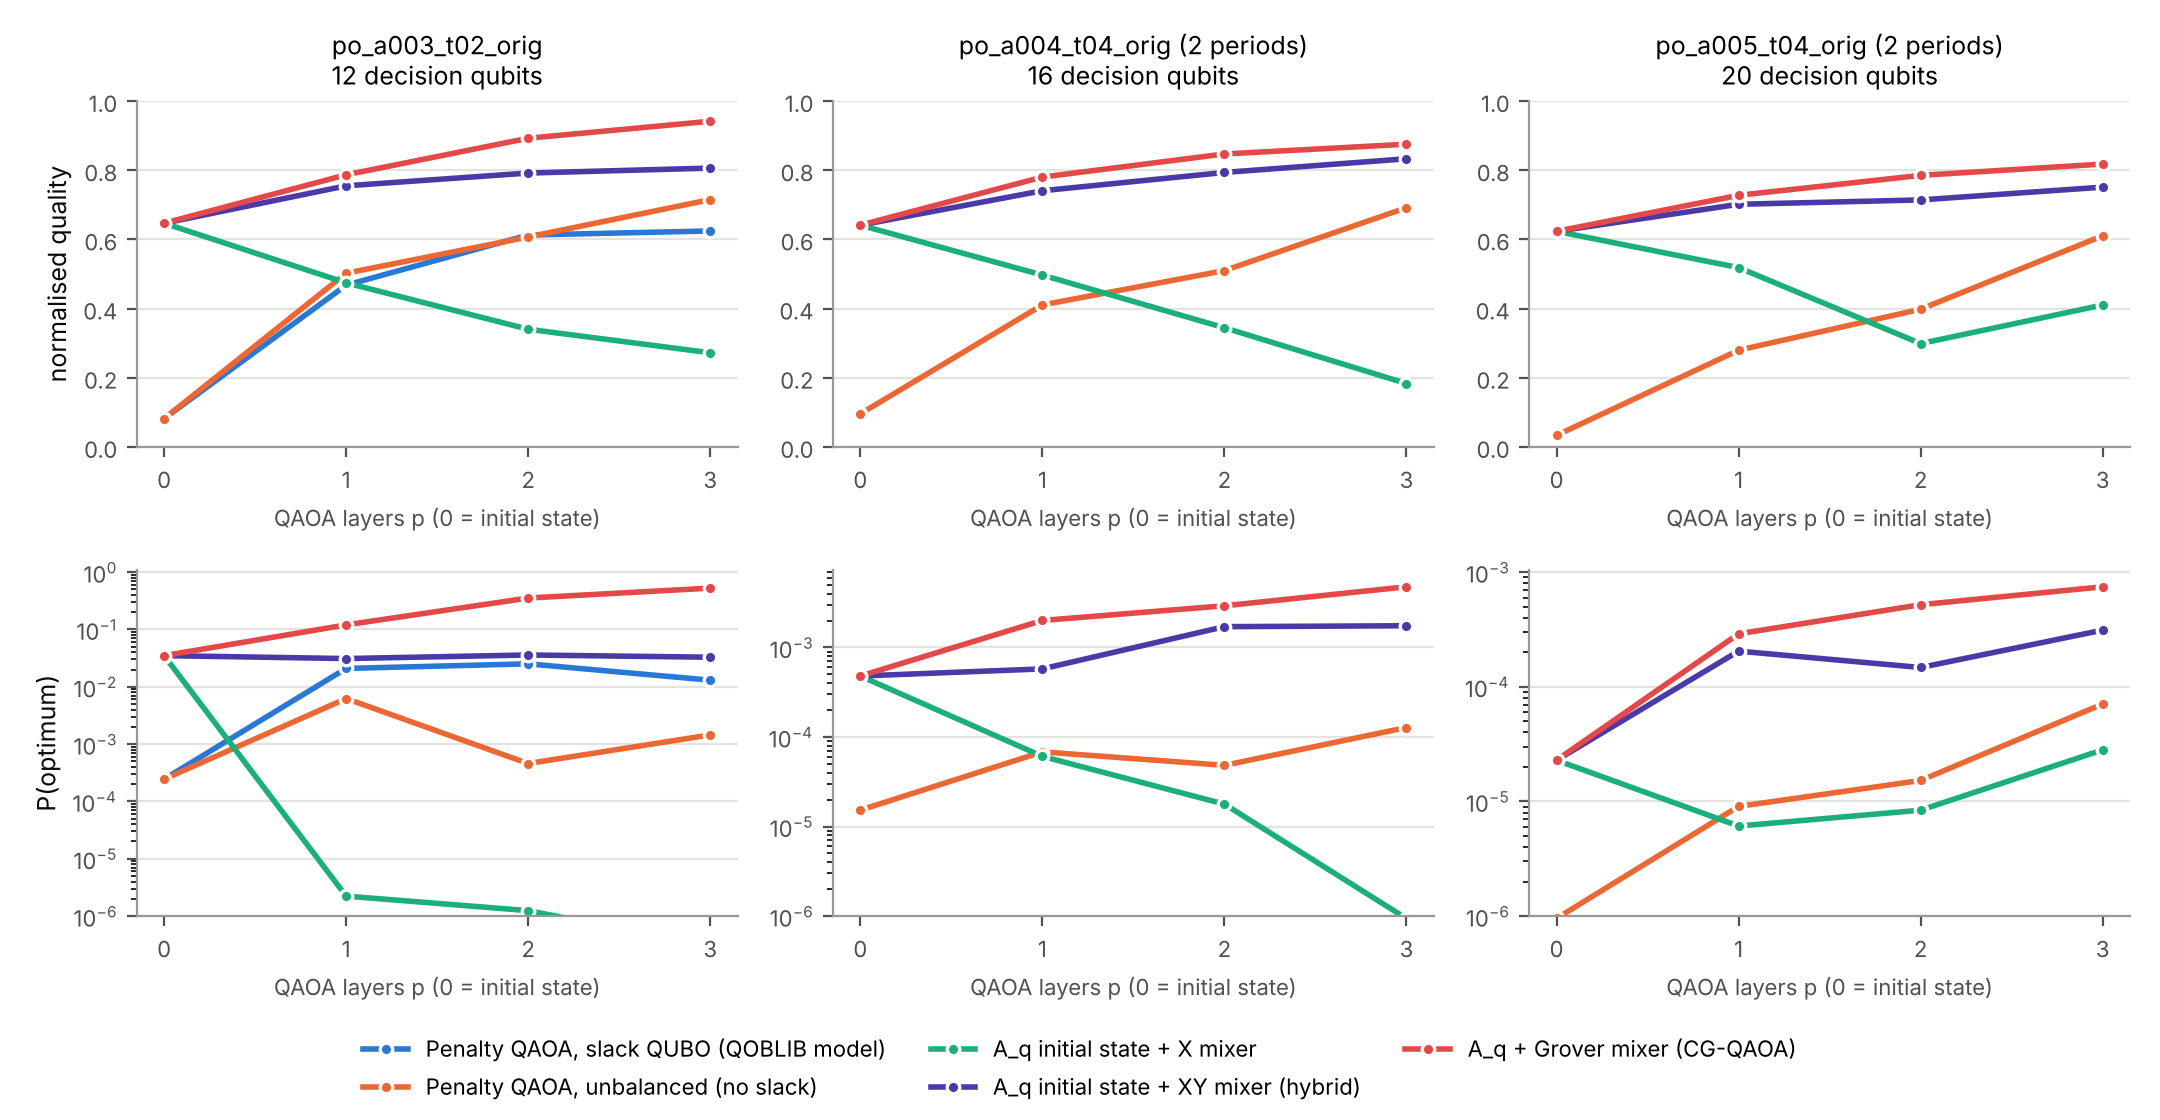

| instance | qubits (ours / slack QUBO) | method | p | P(feasible) | quality | quality of feasible samples | P(opt) |
|---|---|---|---|---|---|---|---|
| po_a003_t02_orig | 12 / 20 | uniform sampling | 0 | 0.165 | 0.082 | 0.498 | 2.4e-04 |
| | | A_q alone (q=0.05) | 0 | 1.000 | 0.647 | 0.647 | 3.5e-02 |
| | | Penalty QAOA, slack QUBO (QOBLIB model) | 1 | 0.583 | 0.468 | 0.803 | 2.1e-02 |
| | | Penalty QAOA, unbalanced (no slack) | 1 | 0.630 | 0.502 | 0.798 | 6.2e-03 |
| | | A_q initial state + X mixer | 1 | 0.958 | 0.475 | 0.495 | 2.2e-06 |
| | | A_q initial state + XY mixer (hybrid) | 1 | 1.000 | 0.755 | 0.755 | 3.1e-02 |
| | | A_q + Grover mixer (CG-QAOA) | 1 | 1.000 | 0.787 | 0.787 | 1.2e-01 |
| | | Penalty QAOA, slack QUBO (QOBLIB model) | 2 | 0.723 | 0.613 | 0.848 | 2.5e-02 |
| | | Penalty QAOA, unbalanced (no slack) | 2 | 0.786 | 0.607 | 0.773 | 4.6e-04 |
| | | A_q initial state + X mixer | 2 | 0.696 | 0.341 | 0.489 | 1.2e-06 |
| | | A_q initial state + XY mixer (hybrid) | 2 | 1.000 | 0.792 | 0.792 | 3.6e-02 |
| | | A_q + Grover mixer (CG-QAOA) | 2 | 1.000 | 0.893 | 0.893 | 3.5e-01 |
| | | Penalty QAOA, slack QUBO (QOBLIB model) | 3 | 0.769 | 0.625 | 0.812 | 1.3e-02 |
| | | Penalty QAOA, unbalanced (no slack) | 3 | 0.811 | 0.715 | 0.882 | 1.4e-03 |
| | | A_q initial state + X mixer | 3 | 0.572 | 0.272 | 0.476 | 3.0e-07 |
| | | A_q initial state + XY mixer (hybrid) | 3 | 1.000 | 0.806 | 0.806 | 3.3e-02 |
| | | A_q + Grover mixer (CG-QAOA) | 3 | 1.000 | 0.942 | 0.942 | 5.3e-01 |
| po_a004_t04_orig (2 periods) | 16 / 26 | uniform sampling | 0 | 0.175 | 0.096 | 0.549 | 1.5e-05 |
| | | A_q alone (q=0.15) | 0 | 1.000 | 0.641 | 0.641 | 4.8e-04 |
| | | Penalty QAOA, unbalanced (no slack) | 1 | 0.559 | 0.411 | 0.734 | 6.8e-05 |
| | | A_q initial state + X mixer | 1 | 0.811 | 0.497 | 0.613 | 6.1e-05 |
| | | A_q initial state + XY mixer (hybrid) | 1 | 1.000 | 0.741 | 0.741 | 5.8e-04 |
| | | A_q + Grover mixer (CG-QAOA) | 1 | 1.000 | 0.780 | 0.780 | 2.0e-03 |
| | | Penalty QAOA, unbalanced (no slack) | 2 | 0.614 | 0.510 | 0.830 | 4.8e-05 |
| | | A_q initial state + X mixer | 2 | 0.548 | 0.345 | 0.629 | 1.8e-05 |
| | | A_q initial state + XY mixer (hybrid) | 2 | 1.000 | 0.794 | 0.794 | 1.7e-03 |
| | | A_q + Grover mixer (CG-QAOA) | 2 | 1.000 | 0.847 | 0.847 | 2.9e-03 |
| | | Penalty QAOA, unbalanced (no slack) | 3 | 0.808 | 0.692 | 0.856 | 1.3e-04 |
| | | A_q initial state + X mixer | 3 | 0.287 | 0.184 | 0.639 | 9.4e-07 |
| | | A_q initial state + XY mixer (hybrid) | 3 | 1.000 | 0.833 | 0.833 | 1.7e-03 |
| | | A_q + Grover mixer (CG-QAOA) | 3 | 1.000 | 0.875 | 0.875 | 4.8e-03 |
| po_a005_t04_orig (2 periods) | 20 / 30 | uniform sampling | 0 | 0.060 | 0.034 | 0.562 | 9.5e-07 |
| | | A_q alone (q=0.10) | 0 | 1.000 | 0.624 | 0.624 | 2.3e-05 |
| | | Penalty QAOA, unbalanced (no slack) | 1 | 0.429 | 0.280 | 0.652 | 9.0e-06 |
| | | A_q initial state + X mixer | 1 | 0.869 | 0.519 | 0.597 | 6.1e-06 |
| | | A_q initial state + XY mixer (hybrid) | 1 | 1.000 | 0.702 | 0.702 | 2.0e-04 |
| | | A_q + Grover mixer (CG-QAOA) | 1 | 1.000 | 0.728 | 0.728 | 2.9e-04 |
| | | Penalty QAOA, unbalanced (no slack) | 2 | 0.548 | 0.398 | 0.728 | 1.5e-05 |
| | | A_q initial state + X mixer | 2 | 0.484 | 0.299 | 0.618 | 8.4e-06 |
| | | A_q initial state + XY mixer (hybrid) | 2 | 1.000 | 0.714 | 0.714 | 1.5e-04 |
| | | A_q + Grover mixer (CG-QAOA) | 2 | 1.000 | 0.785 | 0.785 | 5.2e-04 |
| | | Penalty QAOA, unbalanced (no slack) | 3 | 0.839 | 0.611 | 0.728 | 7.1e-05 |
| | | A_q initial state + X mixer | 3 | 0.678 | 0.411 | 0.605 | 2.8e-05 |
| | | A_q initial state + XY mixer (hybrid) | 3 | 1.000 | 0.751 | 0.751 | 3.1e-04 |
| | | A_q + Grover mixer (CG-QAOA) | 3 | 1.000 | 0.818 | 0.818 | 7.4e-04 |


In [6]:
from experiments.portfolio_analysis import merged, METHODS, NAMES
R = merged()
display(Image('figures/fig_portfolio_quality.png', width=900))
display(Markdown(open('tables/portfolio.md').read()))

**Reading the results** (numbers from the table above)

* **The initial state alone is not enough.** $A_q$ followed by the standard X mixer starts 100 % feasible, but the X mixer leaks out of the feasible set and at every depth quality ends below that of the initial state itself. The constraint-guided state helps only if the **mixer also respects the constraints**.
* **Hybrid ($A_q$ + XY).** Inequalities are handled once by $A_q$; the XY mixer moves positions inside each (period, direction) block, conserving #long and #short, so every sample is feasible. Counting infeasible samples as failures, it has higher quality than both penalty encodings (weights tuned) at every depth on the three instances, and a higher P(optimum).
* **Caveat: the feasible samples of penalty QAOA are good.** If infeasible samples are discarded classically, the surviving penalty samples are about as good as, or better than, the hybrid's on the two smaller instances (column *quality of feasible samples*). The hybrid's advantage there is not wasting shots, not better solutions. The reason: XY conserves the number of positions, so only $q$ moves probability between count sectors.
* **CG-QAOA ($A_q$ + Grover mixer)** moves weight across sectors and is best in quality and P(optimum) on every instance, but see the hardware cost below.
* **$A_q$ alone** is classically samplable and already strong. On `po_a003_t02_orig` the hybrid does not raise P(optimum) above $A_q$ alone; on the 16- and 20-qubit instances it does (about 3.5× and 13× at $p=3$).

## 5. What it costs on hardware (`ibm_fez`, CZ gates)

`experiments/portfolio_resources.py`: each circuit transpiled for `FakeFez` (heavy-hex, CZ basis), optimisation level 3, best of 3 seeds. Layer $p\ge2$ is extrapolated from the measured $p=1$ and $p=2$ circuits.

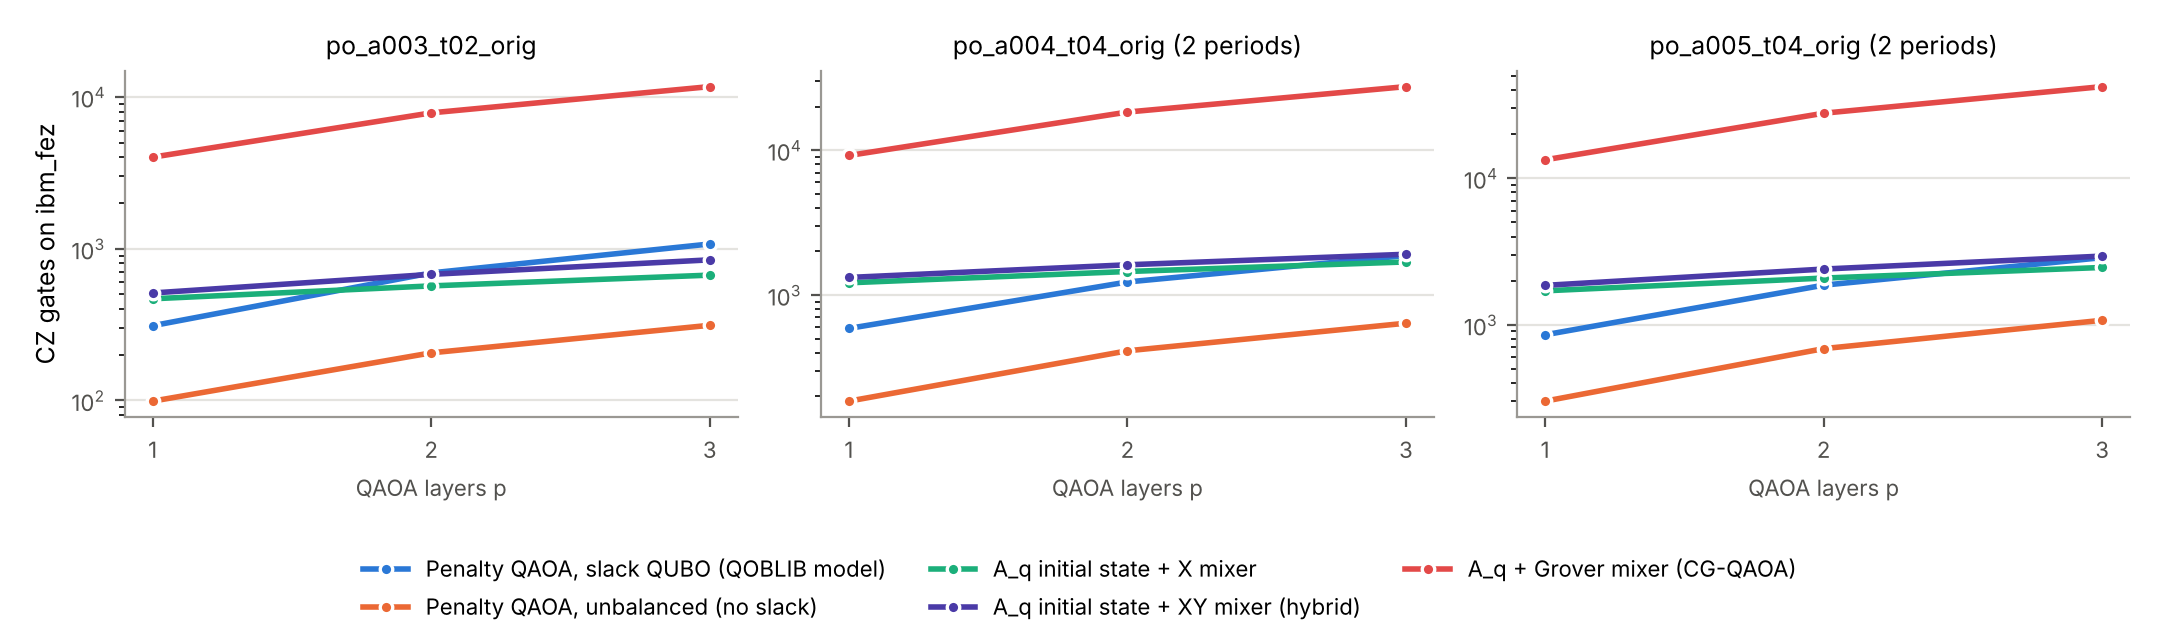

po_a003_t02_orig: A_q alone 324 CZ  |  per extra layer: slack QUBO: 382, unbalanced: 107, A_q+X: 101, A_q+XY: 167, A_q+Grover: 3848
po_a004_t04_orig (2 periods): A_q alone 898 CZ  |  per extra layer: slack QUBO: 643, unbalanced: 227, A_q+X: 239, A_q+XY: 295, A_q+Grover: 9161
po_a005_t04_orig (2 periods): A_q alone 1233 CZ  |  per extra layer: slack QUBO: 1009, unbalanced: 386, A_q+X: 378, A_q+XY: 543, A_q+Grover: 14438


In [7]:
display(Image('figures/fig_portfolio_cz.png', width=900))
Cres = json.load(open('results/portfolio_resources.json'))
SHORT = {'penalty_slack': 'slack QUBO', 'penalty_unbalanced': 'unbalanced', 'A_init_Xmixer': 'A_q+X',
         'A_init_XYmixer': 'A_q+XY', 'A_init_Grover_mixer': 'A_q+Grover'}
for key in Cres:
    c = Cres[key]
    print(f"{NAMES[key]}: A_q alone {c['A_q (preparation only)']['twoq']} CZ  |  per extra layer: " +
          ', '.join(f"{SHORT[m]}: {c[m]['p2_twoq']-c[m]['twoq']}" for m, _, _ in METHODS))

* The **Grover mixer** applies $A_q$ twice more per layer plus a reflection on all qubits: thousands of CZ per layer. It needs fault tolerance.
* The **hybrid** pays for $A_q$ once (counter-based multi-controlled rotations, a few hundred to ~1200 CZ); each extra XY layer costs more than an unbalanced-penalty layer and less than a slack-QUBO layer. It uses $n$ + 3–4 reusable ancillas instead of $n$ + $T(c_1+c_2)$ slack qubits.
* The unbalanced penalty circuit is the cheapest, but a large fraction of its samples are infeasible.

## 6. Does feasibility survive noise? (`ibm_fez` noise model)

Feasibility by construction holds only for a noiseless circuit. `experiments/portfolio_noisy.py` re-runs the optimised circuits with the `FakeFez` noise model (results stored; set `RUN_NOISY_SIM = True` to recompute, which takes tens of minutes). Infeasible samples can always be discarded classically, so we also report quality among the feasible samples.

In [8]:
RUN_NOISY_SIM = False
if RUN_NOISY_SIM:
    import subprocess; subprocess.run([sys.executable, 'experiments/portfolio_noisy.py', '2000'], check=True)
N = json.load(open('results/portfolio_noisy.json'))
print(f"{'circuit':28s} {'CZ':>5s} | {'ideal P(feas)':>13s} {'quality':>8s} | {'noisy P(feas)':>13s} {'quality':>8s} {'qual|feas':>9s} {'P(opt)':>7s}")
for k, v in N.items():
    i, n = v['ideal'], v['noisy']
    print(f"{k:28s} {v['cz']:5d} | {i['p_feas']:13.3f} {i['quality']:8.3f} | {n['p_feas']:13.3f} {n['quality']:8.3f} {n['quality_feasible_only']:9.3f} {n['p_opt']:7.4f}")

circuit                         CZ | ideal P(feas)  quality | noisy P(feas)  quality qual|feas  P(opt)
penalty_unbalanced p=1         101 |         0.634    0.504 |         0.596    0.466     0.782  0.0080
penalty_slack p=1              339 |         0.579    0.466 |         0.468    0.358     0.766  0.0085
A_init_XYmixer p=1             531 |         1.000    0.756 |         0.595    0.394     0.663  0.0135
penalty_unbalanced p=2         206 |         0.781    0.603 |         0.676    0.500     0.740  0.0010
penalty_slack p=2              693 |         0.731    0.622 |         0.518    0.389     0.751  0.0100
A_init_XYmixer p=2             642 |         1.000    0.787 |         0.498    0.333     0.668  0.0140
A_q alone                      324 |         1.000    0.650 |         0.789    0.503     0.638  0.0165


**Reading the noisy results** (`po_a003_t02_orig`, 2000 shots, `ibm_fez` noise model)

* The guarantee is lost under noise. The hybrid's P(feasible) falls from 1.00 to about 0.5–0.6, because its circuit is the deepest (530–640 CZ).
* With today's noise the **cheapest circuit wins on quality**. Unbalanced penalty QAOA (100–200 CZ) keeps quality ≈ 0.47–0.50; the hybrid falls to ≈ 0.33–0.39, about the same as the slack QUBO.
* The hybrid still has the **highest P(optimum)** of the QAOA circuits (≈ 1.3–1.4 % against ≈ 0.1–1 %). Even so, $A_q$ alone, sampled on the noisy device, is as good or better.
* Conclusion for current hardware: the gain from the constraint-guided state is real in the noiseless model, but needs either a cheaper $A_q$ (fewer controlled rotations, better counters, ZX optimisation) or lower error rates before it shows up on a device.

## 6b. Making the hybrid hardware-friendly

Three changes, none of which touches the feasibility guarantee:

1. **Shorts-first order** inside each period: fewer forced counter states, so fewer controlled rotations.
2. **Lean counters**: one counter pair per period (periods prepared in parallel) and **no uncomputation**. After $A_q$ the counters hold (#long, #short) of their period. The XY mixer conserves exactly those numbers and the phase is diagonal, so the measured distribution on the decision qubits is unchanged (verified against the exact state). The measured counters also give a free consistency check.
3. **Sparse phase operator**: the constraints are in the state, not in the cost, so the phase only needs the objective. Its couplings (risk, $\lambda\le 4\cdot10^{-5}$) are small next to the linear terms, and dropping them **does not lower the ideal quality** (`experiments/portfolio_prune.py`). The XY mixer on a path instead of a ring is also enough. Penalty QAOA cannot do this: its penalty is inherently quadratic.

`experiments/portfolio_hardware_opt.py`, `experiments/portfolio_prune.py` and `experiments/portfolio_noisy_lean.py` produce the numbers below.

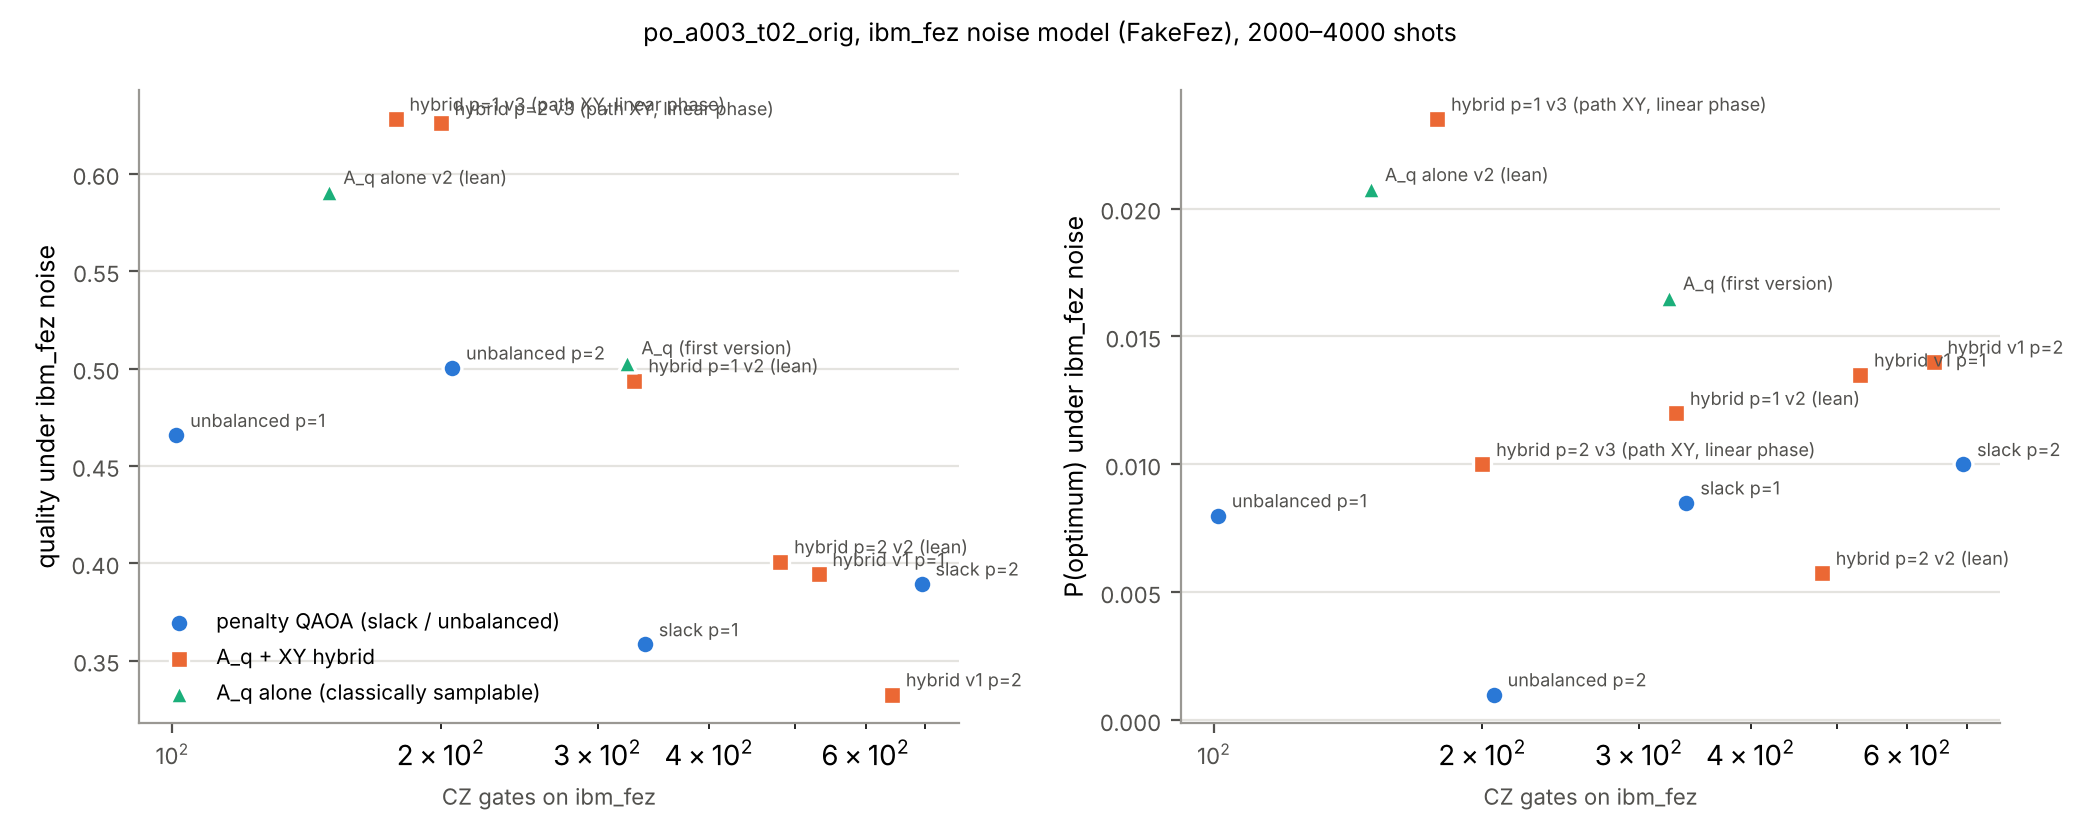

circuit (po_a003_t02_orig)                         CZ depth | noisy: P(feas) quality  P(opt)
A_q alone (lean)                                  150   220 |          0.921   0.591  0.0208
hybrid p=1 (lean)                                 330   387 |          0.711   0.494  0.0120
unbalanced p=1                                     92   128 |          0.574   0.452  0.0070
hybrid p=2 (lean)                                 481   567 |          0.581   0.401  0.0057
unbalanced p=2                                    206   258 |          0.673   0.495  0.0008
hybrid p=1 (lean, path XY, linear phase)          178   225 |          0.848   0.628  0.0235
hybrid p=2 (lean, path XY, linear phase)          200   255 |          0.801   0.626  0.0100


In [9]:
display(Image('figures/fig_portfolio_noisy.png', width=950))
H = json.load(open('results/portfolio_hardware_opt.json'))['a003_t02']['hardware']
L = json.load(open('results/portfolio_noisy_lean.json'))
rows = [(k, v) for k, v in H.items() if 'noisy' in v] + list(L.items())
print(f"{'circuit (po_a003_t02_orig)':48s} {'CZ':>4s} {'depth':>5s} | noisy: {'P(feas)':>7s} {'quality':>7s} {'P(opt)':>7s}")
for k, v in rows:
    n = v['noisy']; print(f"{k:48s} {v['cz']:4d} {v['depth']:5d} | {n['p_feas']:14.3f} {n['quality']:7.3f} {n['p_opt']:7.4f}")

**Reading it.** The cheapest hybrid has about the same CZ count as unbalanced penalty QAOA at $p=2$. Under the `ibm_fez` noise model it gives clearly higher quality and P(optimum) than every penalty circuit, and somewhat more than sampling the lean $A_q$ alone. Caveats:
* These are simulations of the noise model, not a device run. Run section 7 to confirm on hardware.
* Most of the gain comes from the state $A_q$, which is classically samplable. The QAOA layer adds a modest improvement on top.
* With a linear phase, the XY layers on a path are free-fermion (matchgate) dynamics. On instances where the quadratic risk terms matter (larger $\lambda$), the couplings must come back and the circuit gets deeper.

## 7. Run on IBM Quantum hardware

The realistic hardware experiment is the **cheapest hybrid at $p=1$** (section 6b) against **unbalanced penalty QAOA at $p=2$** (similar CZ count) on `po_a003_t02_orig` (parameters taken from the noiseless optimisation). Set `RUN_HARDWARE = True` and point `API_KEY_FILE` to a JSON file `{"apikey": "..."}` (never commit that file).

In [10]:
RUN_HARDWARE = False
API_KEY_FILE = 'apikey_personal.json'
from experiments.portfolio_noisy import stats
Rm = R['a003_t02']['p2']; sc = 1 / np.abs(S.f).max(); D = float(np.abs(P.h).max())
a = Rm['penalty_unbalanced']['alpha']; hu, Ju, cu = P.unbalanced_poly(a * D, a * D); xu = np.array(Rm['penalty_unbalanced']['x'])
Pl = load('a003_t02', order='shorts_first'); Pl.xy_ring = False          # cheapest hybrid (section 6b)
xl = np.array(json.load(open('results/portfolio_prune.json'))['a003_t02']['path_J1.01']['p1']['x'])
circs = {'penalty_unbalanced p=2': qaoa_circuit(P, 'penalty_unbal', (xu[:2], xu[2:4]), h=hu * sc, J={k: v * sc for k, v in Ju.items()}),
         'hybrid p=1 (lean, path XY, linear phase)': qaoa_circuit(Pl, 'cg_xy', (xl[:1], xl[1:2]), q=sig(xl[-1]), h=Pl.h * sc, J={}, counter='lean')}
for c in circs.values(): c.measure_all()
if RUN_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    service = QiskitRuntimeService(channel='ibm_cloud', token=json.load(open(API_KEY_FILE))['apikey'])
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=20)
    sampler = Sampler(mode=backend)
    sampler.options.dynamical_decoupling.enable = True; sampler.options.twirling.enable_gates = True
    job = sampler.run([transpile(c, backend, optimization_level=3) for c in circs.values()], shots=8000)
    print('job_id:', job.job_id())
    for k, pub in zip(circs, job.result()):
        print(k, stats(P, S, pub.data.meas.get_counts()))
else:
    from qiskit_ibm_runtime.fake_provider import FakeFez
    for k, c in circs.items():
        t = transpile(c, FakeFez(), optimization_level=3, seed_transpiler=1)
        print(f"{k:26s} CZ = {t.count_ops().get('cz', 0):4d}  depth = {t.depth()}   (hardware run disabled)")

penalty_unbalanced p=2     CZ =  206  depth = 258   (hardware run disabled)
hybrid p=1 (lean, path XY, linear phase) CZ =  185  depth = 230   (hardware run disabled)


## 8. Summary

| | result |
|---|---|
| **Encoding** | Budget and capital inequalities as negative conditions with exact look-ahead: $A_q|0\rangle$ is supported exactly on the feasible set, with no slack qubits (3–4 reusable ancillas instead of 8–10 slack qubits here). |
| **As QAOA initial state** | Helps only together with a constraint-preserving mixer. With the X mixer quality ends below that of $A_q$ alone at every depth. |
| **Hybrid $A_q$ + XY** | 100 % feasible (noiseless); higher quality and P(optimum) than penalty QAOA (slack or unbalanced, tuned weights) at every depth on the three instances. Per-layer cost lies between the two penalty encodings, plus a one-off cost for $A_q$. After classical filtering of infeasible samples, penalty QAOA is competitive. |
| **Hardware-friendly hybrid** | Shorts-first order, counters not uncomputed, path XY and linear phase: 178–200 CZ on `ibm_fez` for `po_a003_t02_orig`, about the same as unbalanced penalty QAOA at $p=2$. Under the `ibm_fez` noise model: quality ≈ 0.63 vs ≤ 0.50 for every penalty circuit, and P(optimum) up to 2.3 %. Most of the gain comes from $A_q$ itself. |
| **CG-QAOA (Grover mixer)** | Best quality and P(optimum), but thousands of CZ per layer: a fault-tolerant design. |
| **Limits** | Small instances (12–20 decision qubits, `ub = 1`, 2 periods). $A_q$ alone is classically samplable and already strong. On noisy hardware feasibility is no longer guaranteed. Classical MIQP solvers solve these instances instantly. |